Aucune donnée trouvée pour le MMSI 244710000
Analyse pour MMSI 244710000 - 0 enregistrements

=== Changements brutaux de Fréquence (> 0.5 MHz) ===
Aucun changement brutal détecté.

=== Variations brutales de Signal Strength (> 10 dB) ===
Aucune variation brutale détectée.


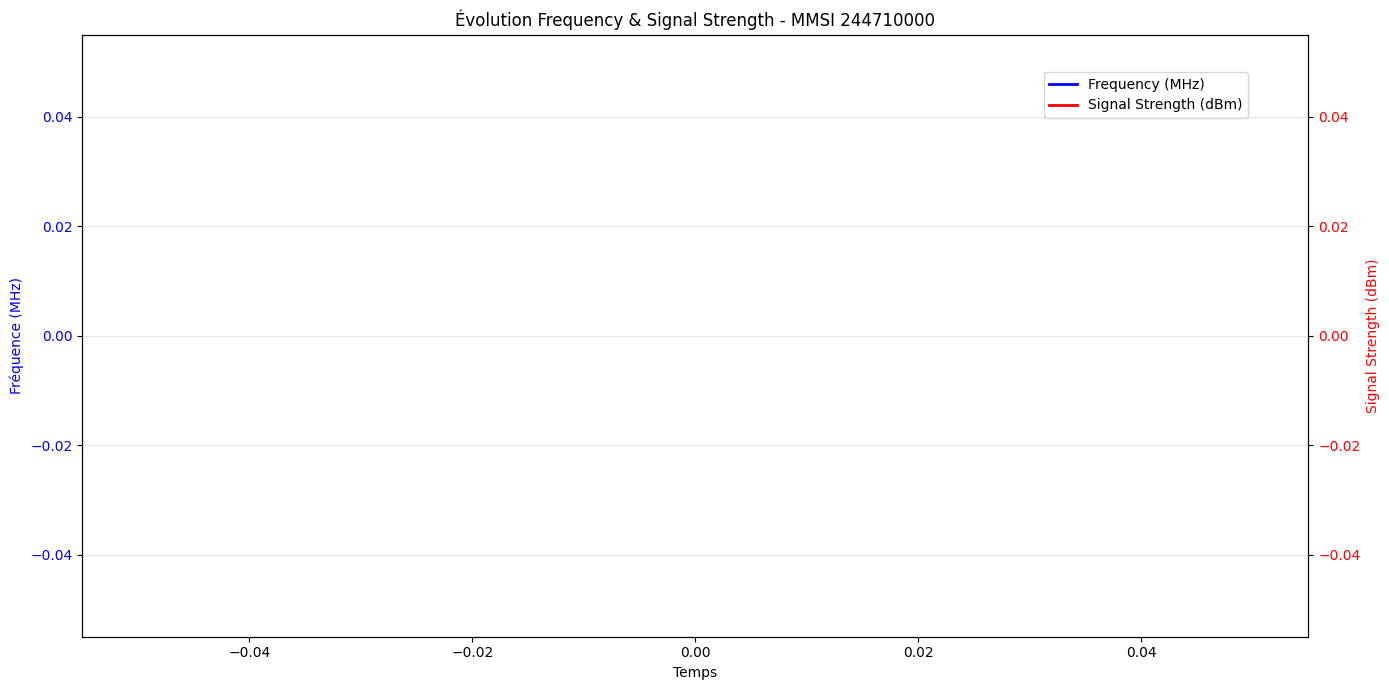

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==================== CONFIGURATION ====================
MMSI = '244710000'
CSV_FILE = 'radio_signatures_large.csv'

THRESHOLD_FREQ = 0.5      # MHz
THRESHOLD_SIGNAL = 10     # dB

# ======================================================

# Chargement des données
df = pd.read_csv(CSV_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Filtrage pour le navire
ship_df = df[df['mmsi'] == MMSI].copy()

if ship_df.empty:
    print(f"Aucune donnée trouvée pour le MMSI {MMSI}")
    exit()

print(f"Analyse pour MMSI {MMSI} - {len(ship_df)} enregistrements")

# ==================== DÉTECTION CHANGEMENTS ====================

# Différences de fréquence
ship_df['freq_diff'] = ship_df['frequency'].diff()
changements_freq = ship_df[abs(ship_df['freq_diff']) > THRESHOLD_FREQ].copy()

# Variations brutales de signal_strength
ship_df['signal_diff'] = ship_df['signal_strength'].diff()
changements_signal = ship_df[abs(ship_df['signal_diff']) > THRESHOLD_SIGNAL].copy()

# ==================== AFFICHAGE RÉSULTATS ====================

print("\n=== Changements brutaux de Fréquence (> {:.1f} MHz) ===".format(THRESHOLD_FREQ))
if not changements_freq.empty:
    print(changements_freq[['timestamp', 'frequency', 'freq_diff']].round(3).to_string(index=False))
else:
    print("Aucun changement brutal détecté.")

print("\n=== Variations brutales de Signal Strength (> {:.0f} dB) ===".format(THRESHOLD_SIGNAL))
if not changements_signal.empty:
    print(changements_signal[['timestamp', 'signal_strength', 'signal_diff']].round(2).to_string(index=False))
else:
    print("Aucune variation brutale détectée.")

# ==================== GRAPHique ====================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Fréquence
ax1.plot(ship_df['timestamp'], ship_df['frequency'], 'b-', linewidth=2, label='Frequency (MHz)')
ax1.set_xlabel('Temps')
ax1.set_ylabel('Fréquence (MHz)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Signal Strength (axe secondaire)
ax2 = ax1.twinx()
ax2.plot(ship_df['timestamp'], ship_df['signal_strength'], 'r-', linewidth=2, label='Signal Strength (dBm)')
ax2.set_ylabel('Signal Strength (dBm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'Évolution Frequency & Signal Strength - MMSI {MMSI}')
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

# Mise en forme
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optionnel : sauvegarde du graphique
# plt.savefig('evolution_mmsi_{}.png'.format(MMSI), dpi=300, bbox_inches='tight')